## Web Scraping

In [1]:
import numpy as np
import pandas as pd
import re
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import time

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import warnings
warnings.filterwarnings('ignore')

# Missing data visualization module for python
import missingno as mno


np.set_printoptions(suppress=True, precision=3)
# choose a matplotlib style option
plt.style.use('fivethirtyeight')

# choose seaborn style option
sns.set_style('darkgrid')


In [2]:
url="https://traveltriangle.com/tour-packages/india/page/1"

In [3]:
response=requests.get(url)
response

<Response [200]>

In [4]:
response.text[:100]

'<!doctype html><html lang="en" data-reactroot=""><head><link href="https://assets.traveltriangle.com'

In [5]:
response.content[:100]

b'<!doctype html><html lang="en" data-reactroot=""><head><link href="https://assets.traveltriangle.com'

In [6]:
page_content=response.text

In [7]:
soup=BeautifulSoup(page_content)

In [8]:
package_heading=soup.find("ul",attrs={"class":"clearfix package-cities-list at_packagecity_list"})

In [9]:
package_heading

<ul class="clearfix package-cities-list at_packagecity_list"><li class="f12">Goa<!-- --> (5D)</li></ul>

In [10]:
Package_Heading=[]
for x in soup.find_all("span",attrs={"class":"fw9 m0 f16 pfc3"}):
    Package_Heading.append(x.text if x else np.nan)
for i in Package_Heading:
    print(i)

Most Reasonable Goa Honeymoon Tour Packages
Fantastic Andaman Honeymoon Package
Romantic Mussoorie Tour Package From Delhi
Coorg Package For 2 Nights And 3 Days
Best 4N 5D Andaman Sightseeing Tour Package For A Refreshing Getaway
Mesmerising Manali Trip Package From Chandigarh
Hills & Houseboat: Munnar and Alleppey Honeymoon Package 
Top Family Holiday Packages in Goa for an Ideal Family Vacation
Most Affordable 1 Night 2 Days Uttarakhand Tour Packages From Delhi
Top 4 Nights 5 Days Best-Selling Sikkim Gangtok Darjeeling Tour Package
Best 5 Night 6 Day Leh Ladakh Tour Package For A Fun Filled Vacay
Postcard-Perfect Sikkim Gangtok Lachung Honeymoon Packages
Best Selling Kerala Houseboat & Jungle Safari Tour Package
Go on an excursion to Shillong to witness the best of natural attraction
Top 5 Nights 6 Days Kerala Family Tour Packages For A Refreshing Getaway
Exciting Goa Tour Packages For A Perfect Getaway
Discover Our Beautiful 4 Nights 5 Days Andaman Family Tour Packages
4 Nights 5 Da

In [22]:
City_names=[]
for x in soup.find_all("ul",attrs={"class":"clearfix package-cities-list at_packagecity_list"}):
    City_names.append(x.text if x else np.nan)
for i in City_names:
    print(i)


Goa (5D)
Port Blair (3D)Havelock (2D)
Mussoorie (3D)
Coorg (3D)
Port Blair (4D)Havelock (1D)
Manali (3D)
Munnar (2D)Thekkady (1D)Alleppey (1D)Kochi (2D)
Calangute (5D)
Rishikesh (2D)
Gangtok (2D)Darjeeling (3D)
Leh (5D)Nubra Valley (1D)
Gangtok (4D)Lachung (1D)
Munnar (2D)Thekkady (1D)Alleppey (2D)
Kaziranga (2D)Shillong (2D)Guwahati (2D)
Munnar (2D)Thekkady (1D)Alleppey (1D)Kochi (2D)
Goa (3D)
Port Blair (4D)Havelock (1D)
Gangtok (4D)Lachung (1D)
Shimla (3D)
Katra (1D)Pahalgam (1D)Srinagar (4D)Gulmarg (1D)


In [12]:
for i in range(1,194):
    print(f"https://traveltriangle.com/tour-packages/india/page/{i}")

https://traveltriangle.com/tour-packages/india/page/1
https://traveltriangle.com/tour-packages/india/page/2
https://traveltriangle.com/tour-packages/india/page/3
https://traveltriangle.com/tour-packages/india/page/4
https://traveltriangle.com/tour-packages/india/page/5
https://traveltriangle.com/tour-packages/india/page/6
https://traveltriangle.com/tour-packages/india/page/7
https://traveltriangle.com/tour-packages/india/page/8
https://traveltriangle.com/tour-packages/india/page/9
https://traveltriangle.com/tour-packages/india/page/10
https://traveltriangle.com/tour-packages/india/page/11
https://traveltriangle.com/tour-packages/india/page/12
https://traveltriangle.com/tour-packages/india/page/13
https://traveltriangle.com/tour-packages/india/page/14
https://traveltriangle.com/tour-packages/india/page/15
https://traveltriangle.com/tour-packages/india/page/16
https://traveltriangle.com/tour-packages/india/page/17
https://traveltriangle.com/tour-packages/india/page/18
https://traveltrian

In [13]:
Package_Title = []
City_name = []
Hotel_type = []
Original_Price = []
Discount_Percent = []
Final_Price = []
Duration = []
Package_Features = []



total_time = time.time()

for i in range(1, 194): 
    start_time = time.time()
    url=f"https://traveltriangle.com/tour-packages/india/page/{i}"    
    page = requests.get(url)
    soup = BeautifulSoup(page.text, "html.parser")

    for x in soup.find_all('div', attrs={'class':'col-12 p8 pt0'}):
        PackageTitle = x.find('span', attrs={'class':'fw9 m0 f16 pfc3'})
        city = x.find("ul",attrs={"class":"clearfix package-cities-list at_packagecity_list"})   # discounted price
        HotelType = x.find('label', attrs={'class':'pr0 pt0 pl20'})   # discounted price
        OriginalPrice = x.find('span', attrs={'class':'f12 pfc3 tdl ml8 at_oldprice fw4'})
        DiscountPercent = x.find('span', attrs={'class':'f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label'})
        FinalPrice = x.find('p', attrs={'class':'sfc3 m0 f20 fw9 priceVal at_newprice'})
        duration = x.find('span', attrs={'class':'iblock sfc6'})
        PackageFeatures = x.find('li', attrs={'class':'ellipsis'})
        

        Package_Title.append(PackageTitle.text if PackageTitle else np.nan)
        City_name.append(city.text if city else np.nan)
        Hotel_type.append(HotelType.text if HotelType else np.nan)
        Original_Price.append(OriginalPrice.text if OriginalPrice else np.nan)
        Discount_Percent.append(DiscountPercent.text if DiscountPercent else np.nan)
        Final_Price.append(FinalPrice.text if FinalPrice else np.nan)
        Duration.append(duration.text if duration else np.nan)
        Package_Features.append(PackageFeatures.text if PackageFeatures else np.nan)
        

    print(f'Page {i} completed in {time.time()-start_time:.2f} seconds')

print("Total Time Completed in seconds", str(time.time()-total_time))


Page 1 completed in 3.48 seconds
Page 2 completed in 5.07 seconds
Page 3 completed in 4.68 seconds
Page 4 completed in 3.87 seconds
Page 5 completed in 5.01 seconds
Page 6 completed in 5.16 seconds
Page 7 completed in 6.49 seconds
Page 8 completed in 5.26 seconds
Page 9 completed in 8.65 seconds
Page 10 completed in 10.31 seconds
Page 11 completed in 14.38 seconds
Page 12 completed in 10.16 seconds
Page 13 completed in 5.60 seconds
Page 14 completed in 5.23 seconds
Page 15 completed in 5.45 seconds
Page 16 completed in 5.68 seconds
Page 17 completed in 7.33 seconds
Page 18 completed in 10.16 seconds
Page 19 completed in 12.22 seconds
Page 20 completed in 6.60 seconds
Page 21 completed in 9.06 seconds
Page 22 completed in 8.60 seconds
Page 23 completed in 5.08 seconds
Page 24 completed in 4.94 seconds
Page 25 completed in 4.10 seconds
Page 26 completed in 9.56 seconds
Page 27 completed in 9.36 seconds
Page 28 completed in 4.68 seconds
Page 29 completed in 6.09 seconds
Page 30 completed 

In [14]:
Travel_df=pd.DataFrame({"Package_Title":Package_Title,"City_Name":City_name,"Hotel_type":Hotel_type,"Original_Price":Original_Price
                        ,"Discount_Percent":Discount_Percent,"Final_Price":Final_Price,"Duration":Duration,
                       "Package_Features":Package_Features})

In [15]:
Travel_df.head()

,Package_Title,City_Name,Hotel_type,Original_Price,Discount_Percent,Final_Price,Duration,Package_Features
0,Most Reasonable Goa Honeymoon Tour Packages,Goa (5D),3 Star,"â¹ 9,142/-",13% Off,"â¹ 7,999/-â¹ 9,142/-",5 Days & 4 Nights,Hot Pick
1,Fantastic Andaman Honeymoon Package,Port Blair (3D)Havelock (2D),3 Star,"â¹ 18,811/-",17% Off,"â¹ 15,599/-â¹ 18,811/-",5 Days & 4 Nights,Corbyn's Beach Cove
2,Romantic Mussoorie Tour Package From Delhi,Mussoorie (3D),3 Star,"â¹ 12,000/-",13% Off,"â¹ 10,500/-â¹ 12,000/-",3 Days & 2 Nights,Sightseeing
3,Coorg Package For 2 Nights And 3 Days,Coorg (3D),3 Star,"â¹ 15,934/-",9% Off,"â¹ 14,500/-â¹ 15,934/-",3 Days & 2 Nights,Coorg sightseeing
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,Port Blair (4D)Havelock (1D),3 Star,"â¹ 36,484/-",9% Off,"â¹ 33,200/-â¹ 36,484/-",5 Days & 4 Nights,Cellular Jail


In [16]:
Travel_df.to_csv('Travel_Triangles.csv',index=False)

In [17]:
df=pd.read_csv('Travel_Triangles.csv')

In [116]:
df['Discount_Percent']=df.Discount_Percent.str.replace('% Off','')

In [117]:
df['Discount_Percent'].isna().sum()

2

In [18]:
df

,Package_Title,City_Name,Hotel_type,Original_Price,Discount_Percent,Final_Price,Duration,Package_Features
0,Most Reasonable Goa Honeymoon Tour Packages,Goa (5D),3 Star,"â¹ 9,142/-",13% Off,"â¹ 7,999/-â¹ 9,142/-",5 Days & 4 Nights,Hot Pick
1,Fantastic Andaman Honeymoon Package,Port Blair (3D)Havelock (2D),3 Star,"â¹ 18,811/-",17% Off,"â¹ 15,599/-â¹ 18,811/-",5 Days & 4 Nights,Corbyn's Beach Cove
2,Romantic Mussoorie Tour Package From Delhi,Mussoorie (3D),3 Star,"â¹ 12,000/-",13% Off,"â¹ 10,500/-â¹ 12,000/-",3 Days & 2 Nights,Sightseeing
3,Coorg Package For 2 Nights And 3 Days,Coorg (3D),3 Star,"â¹ 15,934/-",9% Off,"â¹ 14,500/-â¹ 15,934/-",3 Days & 2 Nights,Coorg sightseeing
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,Port Blair (4D)Havelock (1D),3 Star,"â¹ 36,484/-",9% Off,"â¹ 33,200/-â¹ 36,484/-",5 Days & 4 Nights,Cellular Jail
...,...,...,...,...,...,...,...,...
3811,5-Day Kerala Family Tour with Munnar and Backw...,Munnar (2D)Thekkady (1D)Alleppey (1D)Cochin (1D),4 Star,"â¹ 46,900/-",11% Off,"â¹ 41,741/-â¹ 46,900/-",5 Days & 4 Nights,Quote Package
3812,"5-Day Enchanting Kerala Tour with Munnar, Thek...",Munnar (2D)Thekkady (1D)Alleppey (1D)Cochin (1D),3 Star,"â¹ 44,400/-",11% Off,"â¹ 39,516/-â¹ 44,400/-",5 Days & 4 Nights,Quote Package
3813,5-Day Kerala Tour: Munnar to Alleppey Adventure,Munnar (2D)Thekkady (1D)Alleppey (1D)Cochin (1D),5 Star,"â¹ 61,800/-",13% Off,"â¹ 53,766/-â¹ 61,800/-",5 Days & 4 Nights,Quote Package
3814,3 Nights 4 Days Kerala Trip Packages From Ahme...,Munnar (2D)Alleppey (2D),4 Star,"â¹ 13,708/-",11% Off,"â¹ 12,200/-â¹ 13,708/-",4 Days & 3 Nights,Backwater


In [92]:
df['Original_Price']=df['Original_Price'].apply(lambda x: re.sub(r'[^\d]', '',x)if pd.notnull(x) else '')

In [95]:
df['Original_Price']=df['Original_Price'].astype(int)

In [70]:
df['Original_Price'].fillna(round(df['Original_Price'].mean(),0),inplace=True)

In [81]:
df['Original_Price'].isna().sum()

0

In [91]:
df['Original_Price']=df['Original_Price'].astype(str)

In [ ]:
df['Original_Price_Clean'] = df['Original_Price'].apply(
    lambda x: re.sub(r'[^\d]', '', re.search(r'(\d[\d,]*)', str(x)).group(1))
    if re.search(r'(\d[\d,]*)', str(x)) else None
)


In [84]:
df['Final_Price']=df['Final_Price'].apply(lambda x: re.sub(r'[^\d]', '', re.search(r'(\d[\d,]*)', str(x)).group(1))
                          if re.search(r'(\d[\d,]*)', str(x)) else None)

In [86]:
df['Final_Price'].isna().sum()

0

In [88]:
df['Final_Price']=df['Final_Price'].astype(int)

In [90]:
df['Final_Price'].dtype

dtype('int32')

In [ ]:
df['City_name_Clean'] = df['City_name'].apply(
    lambda x: re.sub(r'(?<=[a-zA-Z])(?=[A-Z])', ', ', 
                     re.sub(r'\(\d+D\)', '', str(x)).strip())
)


In [107]:
df['City_Name']=df['City_Name'].apply(
    lambda x: re.sub(
        r'\s+(?=[A-Z])', ', ',           # insert comma before next uppercase word
        re.sub(r'\(\d+D\)', '', str(x))  # remove (2D), (1D), etc.
    ).strip()
)


In [111]:
df.drop('City_Name_Clean',axis=1,inplace=True)

In [112]:
df.columns

Index(['Package_Title', 'City_Name', 'Hotel_type', 'Original_Price',
       'Discount_Percent', 'Final_Price', 'Duration', 'Package_Features'],
      dtype='object')

In [125]:
df['Discount_Percent'].mode()[0]

'9'

In [127]:
df['Discount_Percent']=df['Discount_Percent'].fillna(df['Discount_Percent'].mode()[0])

In [129]:
df['Discount_Percent']=df['Discount_Percent'].astype(int)

In [140]:
df['Number_Of_days']=df['Duration'].apply(
    lambda x: re.search(r'\d+', str(x)).group() if re.search(r'\d+', str(x)) else None)

In [141]:
df['Number_Of_days'].isna().sum()

0

In [143]:
df['Number_Of_days']=df['Number_Of_days'].astype('int')

In [144]:
df

,Package_Title,City_Name,Hotel_type,Original_Price,Discount_Percent,Final_Price,Duration,Package_Features,Number_Of_days
0,Most Reasonable Goa Honeymoon Tour Packages,Goa,3 Star,9142,13,7999,5 Days & 4 Nights,Hot Pick,5
1,Fantastic Andaman Honeymoon Package,"Port, Blair, Havelock",3 Star,18811,17,15599,5 Days & 4 Nights,Corbyn's Beach Cove,5
2,Romantic Mussoorie Tour Package From Delhi,Mussoorie,3 Star,12000,13,10500,3 Days & 2 Nights,Sightseeing,3
3,Coorg Package For 2 Nights And 3 Days,Coorg,3 Star,15934,9,14500,3 Days & 2 Nights,Coorg sightseeing,3
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,"Port, Blair, Havelock",3 Star,36484,9,33200,5 Days & 4 Nights,Cellular Jail,5
...,...,...,...,...,...,...,...,...,...
3811,5-Day Kerala Family Tour with Munnar and Backw...,"Munnar, Thekkady, Alleppey, Cochin",4 Star,46900,11,41741,5 Days & 4 Nights,Quote Package,5
3812,"5-Day Enchanting Kerala Tour with Munnar, Thek...","Munnar, Thekkady, Alleppey, Cochin",3 Star,44400,11,39516,5 Days & 4 Nights,Quote Package,5
3813,5-Day Kerala Tour: Munnar to Alleppey Adventure,"Munnar, Thekkady, Alleppey, Cochin",5 Star,61800,13,53766,5 Days & 4 Nights,Quote Package,5
3814,3 Nights 4 Days Kerala Trip Packages From Ahme...,"Munnar, Alleppey",4 Star,13708,11,12200,4 Days & 3 Nights,Backwater,4


In [147]:
df['Price_Per_Day']=round(df['Original_Price']/df['Number_Of_days'],2)

In [148]:
df

,Package_Title,City_Name,Hotel_type,Original_Price,Discount_Percent,Final_Price,Duration,Package_Features,Number_Of_days,Price_Per_Day
0,Most Reasonable Goa Honeymoon Tour Packages,Goa,3 Star,9142,13,7999,5 Days & 4 Nights,Hot Pick,5,1828.40
1,Fantastic Andaman Honeymoon Package,"Port, Blair, Havelock",3 Star,18811,17,15599,5 Days & 4 Nights,Corbyn's Beach Cove,5,3762.20
2,Romantic Mussoorie Tour Package From Delhi,Mussoorie,3 Star,12000,13,10500,3 Days & 2 Nights,Sightseeing,3,4000.00
3,Coorg Package For 2 Nights And 3 Days,Coorg,3 Star,15934,9,14500,3 Days & 2 Nights,Coorg sightseeing,3,5311.33
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,"Port, Blair, Havelock",3 Star,36484,9,33200,5 Days & 4 Nights,Cellular Jail,5,7296.80
...,...,...,...,...,...,...,...,...,...,...
3811,5-Day Kerala Family Tour with Munnar and Backw...,"Munnar, Thekkady, Alleppey, Cochin",4 Star,46900,11,41741,5 Days & 4 Nights,Quote Package,5,9380.00
3812,"5-Day Enchanting Kerala Tour with Munnar, Thek...","Munnar, Thekkady, Alleppey, Cochin",3 Star,44400,11,39516,5 Days & 4 Nights,Quote Package,5,8880.00
3813,5-Day Kerala Tour: Munnar to Alleppey Adventure,"Munnar, Thekkady, Alleppey, Cochin",5 Star,61800,13,53766,5 Days & 4 Nights,Quote Package,5,12360.00
3814,3 Nights 4 Days Kerala Trip Packages From Ahme...,"Munnar, Alleppey",4 Star,13708,11,12200,4 Days & 3 Nights,Backwater,4,3427.00


In [149]:
df.to_csv('Travel_Triangles.csv',index=False)

# Exploratory Data Analysis(EDA)

### Load Dataset

In [2]:
df=pd.read_csv('Travel_Triangles.csv')

In [3]:
df.shape

(3816, 10)

In [4]:
# Check the entire dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3816 entries, 0 to 3815
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Package_Title     3816 non-null   object 
 1   City_Name         3805 non-null   object 
 2   Hotel_type        3723 non-null   object 
 3   Original_Price    3816 non-null   int64  
 4   Discount_Percent  3816 non-null   int64  
 5   Final_Price       3816 non-null   int64  
 6   Duration          3816 non-null   object 
 7   Package_Features  3816 non-null   object 
 8   Number_Of_days    3816 non-null   int64  
 9   Price_Per_Day     3816 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 298.3+ KB


In [5]:
# get the datatypes of the columns
df.dtypes
#count of variables by there dtype
df.dtypes.value_counts()

Package_Title        object
City_Name            object
Hotel_type           object
Original_Price        int64
Discount_Percent      int64
Final_Price           int64
Duration             object
Package_Features     object
Number_Of_days        int64
Price_Per_Day       float64
dtype: object

object     5
int64      4
float64    1
Name: count, dtype: int64

In [6]:
# get the all column names
df.columns

Index(['Package_Title', 'City_Name', 'Hotel_type', 'Original_Price',
       'Discount_Percent', 'Final_Price', 'Duration', 'Package_Features',
       'Number_Of_days', 'Price_Per_Day'],
      dtype='object')

## Check for missing values

In [7]:
df.isna().sum()

Package_Title        0
City_Name           11
Hotel_type          93
Original_Price       0
Discount_Percent     0
Final_Price          0
Duration             0
Package_Features     0
Number_Of_days       0
Price_Per_Day        0
dtype: int64

In [8]:
df.isna().sum().sort_values(ascending=False)

Hotel_type          93
City_Name           11
Package_Title        0
Original_Price       0
Discount_Percent     0
Final_Price          0
Duration             0
Package_Features     0
Number_Of_days       0
Price_Per_Day        0
dtype: int64

In [9]:
# Check missing value percentage for each column
round(((df.isna().sum()/len(df)*100)).sort_values(ascending=False),2).astype(str)+'%'

Hotel_type          2.44%
City_Name           0.29%
Package_Title        0.0%
Original_Price       0.0%
Discount_Percent     0.0%
Final_Price          0.0%
Duration             0.0%
Package_Features     0.0%
Number_Of_days       0.0%
Price_Per_Day        0.0%
dtype: object

### Visualizing the missing values

<Axes: >

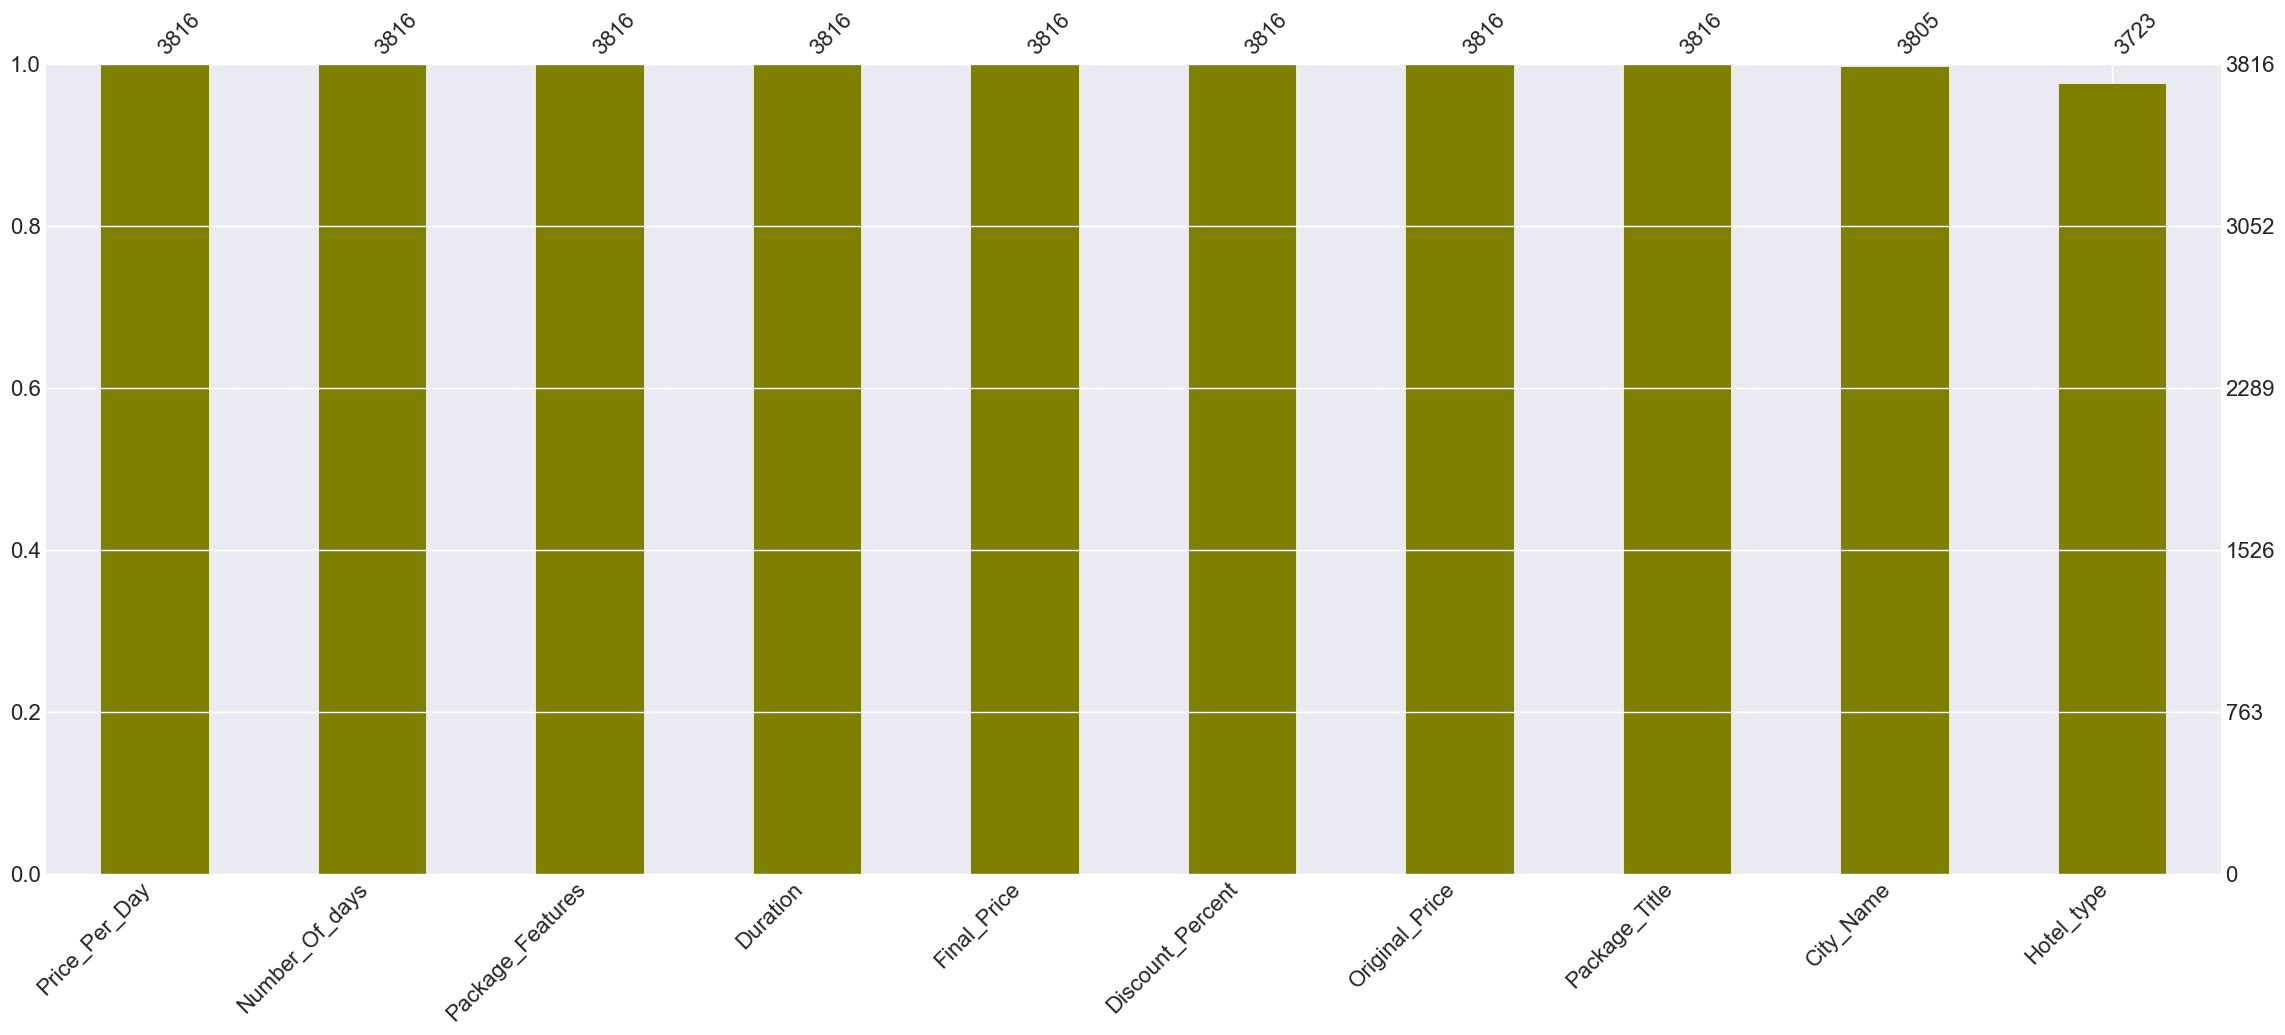

In [10]:
mno.bar(df,color='olive',sort="descending")

In [11]:
df['City_Name'].fillna(df.City_Name.mode()[0],inplace=True)

In [12]:
df['City_Name'].isna().sum()

0

In [13]:
df['Hotel_type'].fillna(df['Hotel_type'].mode()[0],inplace=True)

In [14]:
df['Hotel_type'].isna().sum()

0

## Check for duplicates

In [15]:
df.duplicated().sum()

508

- There are 508 duplicate rows.

In [16]:
# to avoid mislead in analysis drop dupliactes
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

0

In [18]:
df.sort_index(ascending=True,axis=1,inplace=True)

In [19]:
df.head()

,City_Name,Discount_Percent,Duration,Final_Price,Hotel_type,Number_Of_days,Original_Price,Package_Features,Package_Title,Price_Per_Day
0,Goa,13,5 Days & 4 Nights,7999,3 Star,5,9142,Hot Pick,Most Reasonable Goa Honeymoon Tour Packages,1828.40
1,"Port, Blair, Havelock",17,5 Days & 4 Nights,15599,3 Star,5,18811,Corbyn's Beach Cove,Fantastic Andaman Honeymoon Package,3762.20
2,Mussoorie,13,3 Days & 2 Nights,10500,3 Star,3,12000,Sightseeing,Romantic Mussoorie Tour Package From Delhi,4000.00
3,Coorg,9,3 Days & 2 Nights,14500,3 Star,3,15934,Coorg sightseeing,Coorg Package For 2 Nights And 3 Days,5311.33
4,"Port, Blair, Havelock",9,5 Days & 4 Nights,33200,3 Star,5,36484,Cellular Jail,Best 4N 5D Andaman Sightseeing Tour Package Fo...,7296.80


### Check and handle outliers

In [20]:
df.select_dtypes(exclude="object")

,Discount_Percent,Final_Price,Number_Of_days,Original_Price,Price_Per_Day
0,13,7999,5,9142,1828.40
1,17,15599,5,18811,3762.20
2,13,10500,3,12000,4000.00
3,9,14500,3,15934,5311.33
4,9,33200,5,36484,7296.80
...,...,...,...,...,...
3811,11,41741,5,46900,9380.00
3812,11,39516,5,44400,8880.00
3813,13,53766,5,61800,12360.00
3814,11,12200,4,13708,3427.00


In [21]:
#To identify the presence of outliers check the skewness of each column
df.select_dtypes(exclude="object").skew()

Discount_Percent     3.277463
Final_Price          4.974757
Number_Of_days       1.228275
Original_Price       4.912371
Price_Per_Day       28.259210
dtype: float64

In [22]:
# all the columns have less number of outliers except the column Price_Per_Day
#Approach1 IQR to detect outliers
q1,q2,q3=df['Price_Per_Day'].quantile([0.25,0.50,0.75])

In [23]:
IQR=q3-q1
LB=q1-1.5*IQR
UB=q3+1.5*IQR

In [24]:
(df[(df['Price_Per_Day']<LB) | (df['Price_Per_Day']>UB)].shape[0])/len(df)*100

6.045949214026603

In [25]:
(df[(df['Price_Per_Day']>LB) | (df['Price_Per_Day']<UB)].shape[0])/len(df)*100

100.0

- $60.45$ % of outliers are found by IQR method

## 2.Get Outliers using `std` method

In [26]:
mean=df['Price_Per_Day'].mean()
sd=df['Price_Per_Day'].std()
UL=mean+2*sd
LL=mean-2*sd
print(UL,LL)

14705.310946326947 -4082.8910430621336


In [27]:
df.shape

(3308, 10)

In [28]:
df1=df[(df['Price_Per_Day']>=LL) & (df['Price_Per_Day']<=UL)]

### Compute the % of outliers detected by Std Dev method

In [29]:
((df[(df['Price_Per_Day']<LL) | (df['Price_Per_Day']>UL)].shape[0])/len(df))*100

1.8137847642079807

- 1.81% of outliers are identified by std method

In [30]:
df.select_dtypes(exclude='object').skew()

Discount_Percent     3.277463
Final_Price          4.974757
Number_Of_days       1.228275
Original_Price       4.912371
Price_Per_Day       28.259210
dtype: float64

In [31]:
li=["Discount_Percent","Final_Price","Number_Of_days","Original_Price"]

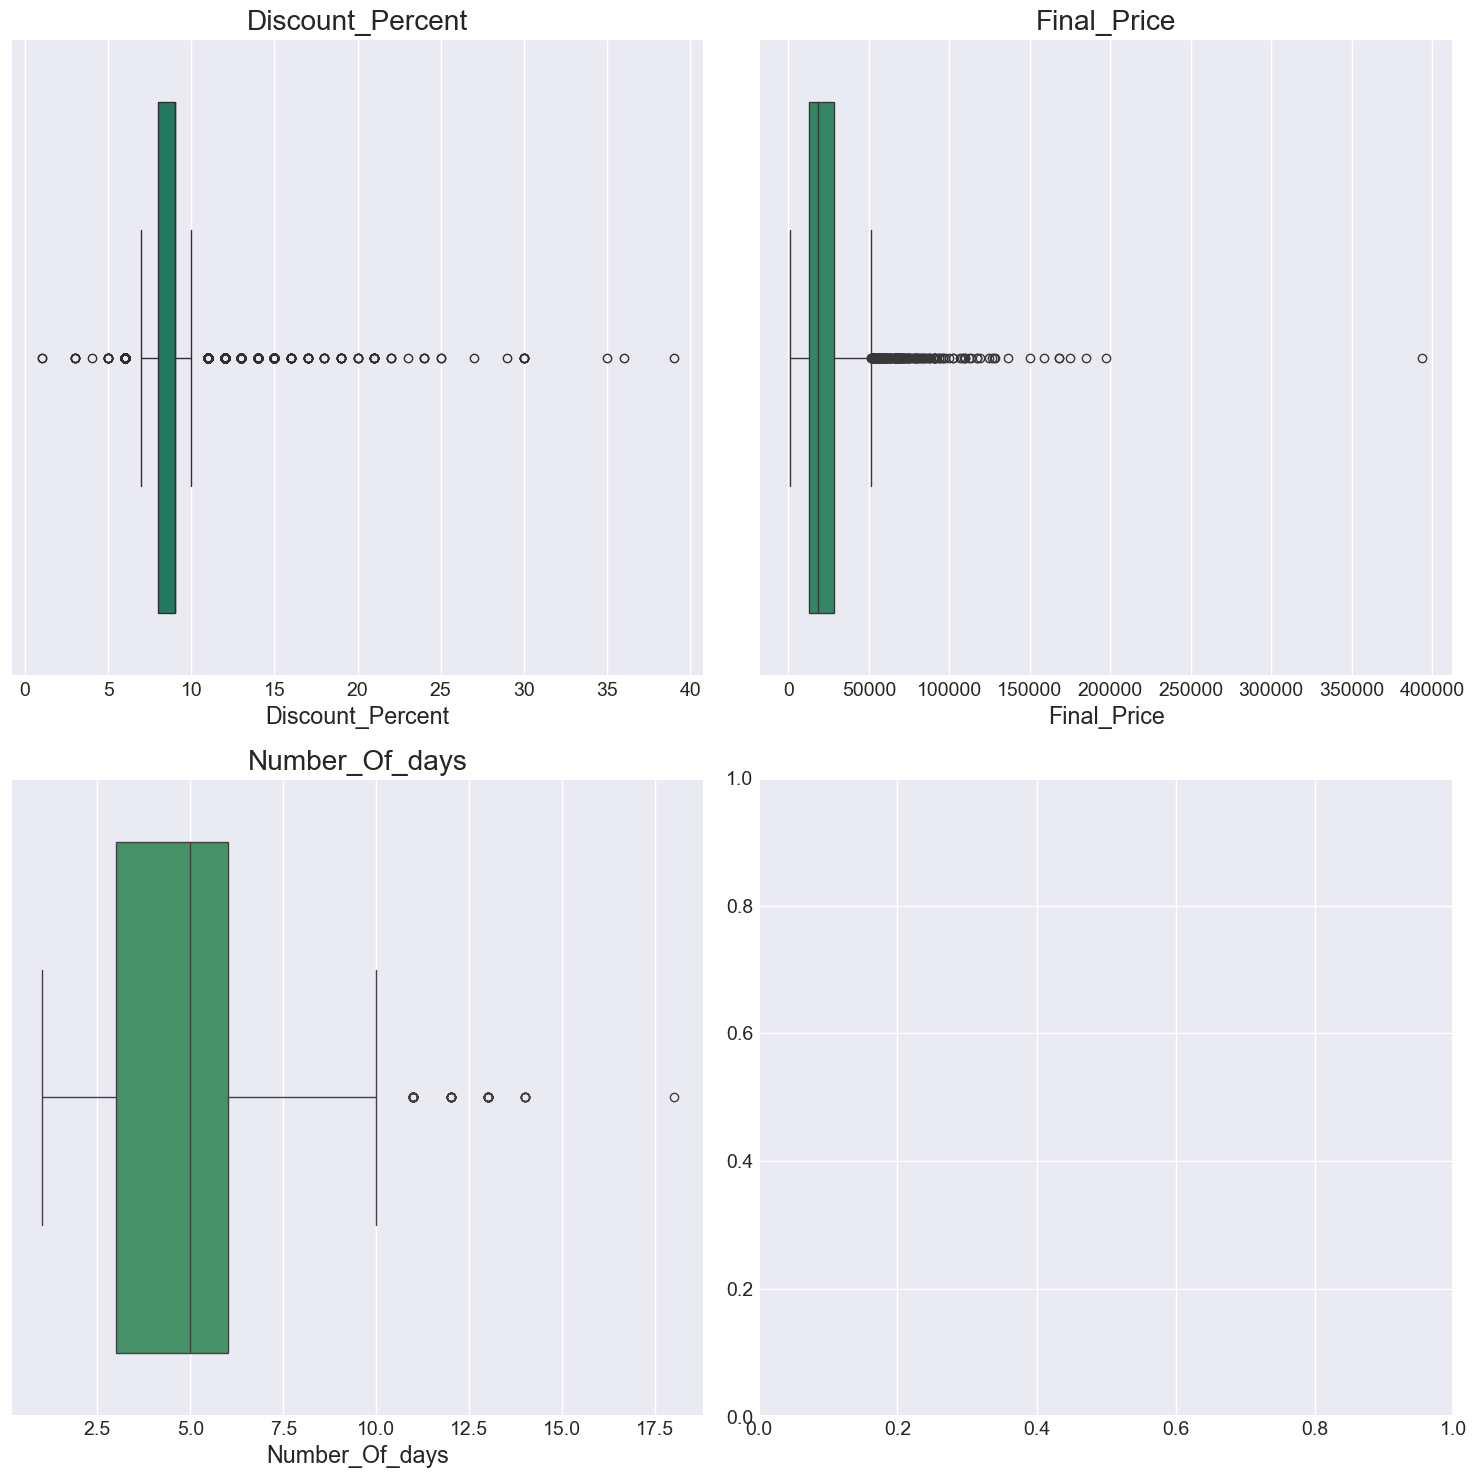

In [32]:
#plot box plot for these 12 columns to detect outliers presence
fig,axis=plt.subplots(nrows=2,ncols=2,figsize=(15,15))
pos=axis.flatten()
for i in range(len(li)-1):
    sns.boxplot(data=df,x=li[i],ax=pos[i],color=sns.color_palette('summer',12)[i])
    pos[i].set_title((f'{li[i]}'))
plt.tight_layout()
plt.show();

## Univariate Analysis

- Numerical columns

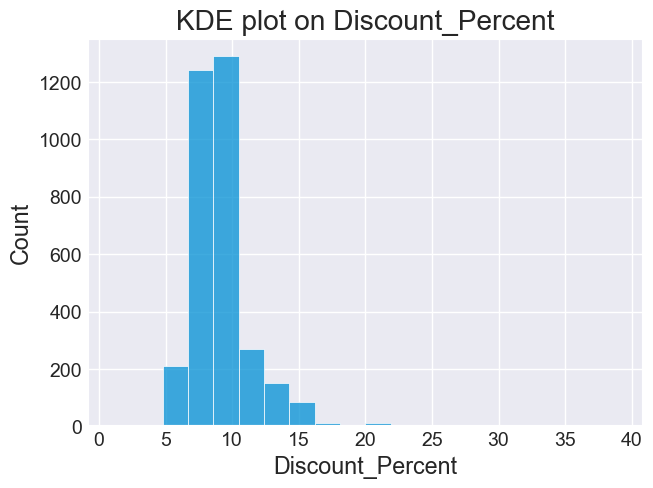

In [33]:
plt.title('KDE plot on Discount_Percent')
sns.histplot(x=df.Discount_Percent,bins=20);

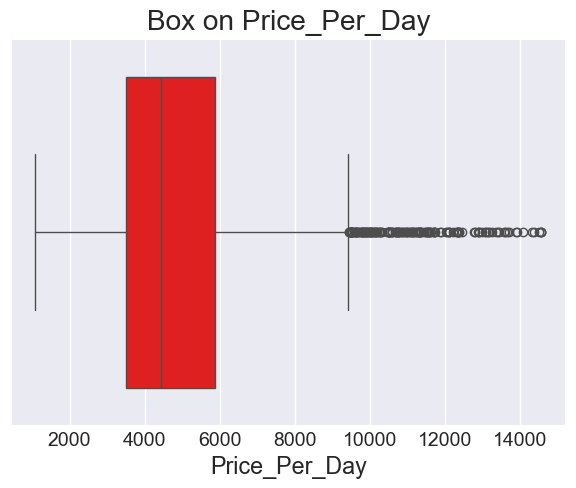

In [34]:
plt.title('Box on Price_Per_Day')
sns.boxplot(df1.Price_Per_Day,orient='h',color='red');

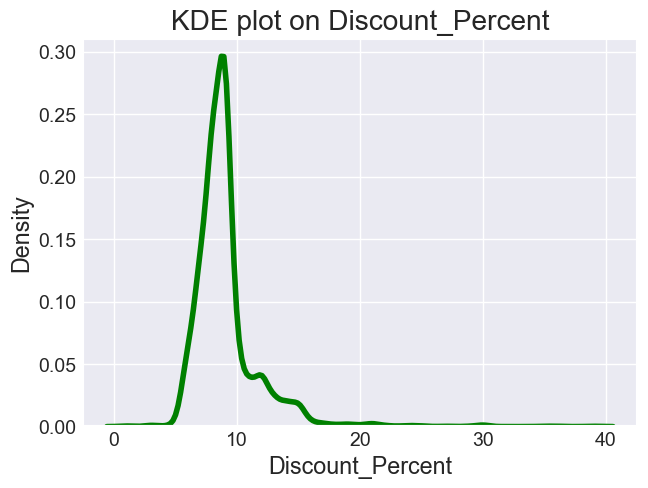

In [35]:
plt.title('KDE plot on Discount_Percent')
sns.kdeplot(x=df1.Discount_Percent,color='green');

- Categorical columns

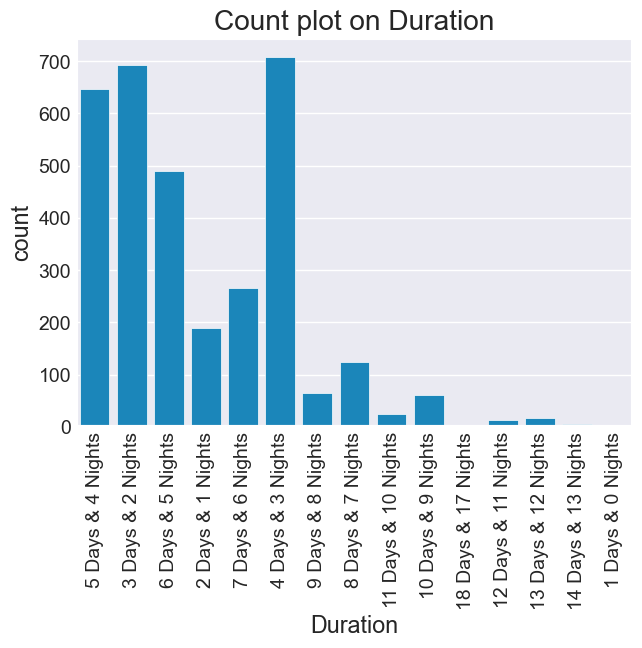

In [36]:
plt.title('Count plot on Duration')
sns.countplot(x=df.Duration)
plt.xticks(rotation=90);

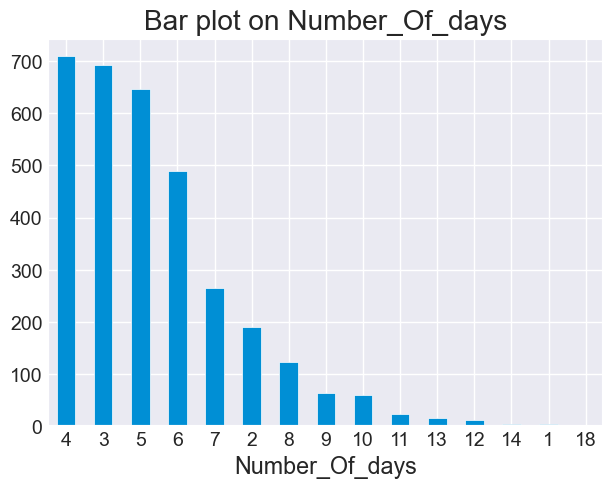

In [37]:
plt.title('Bar plot on Number_Of_days')
df['Number_Of_days'].value_counts().plot(kind='bar')
plt.xticks(rotation=0);

## Bivariate Analysis

- Two Numerical

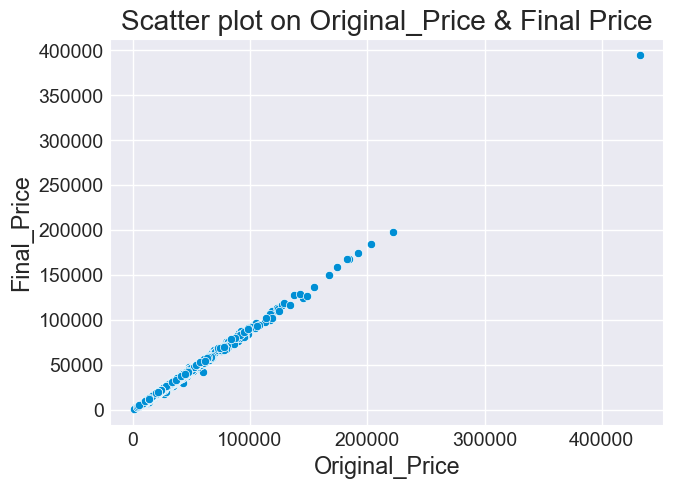

In [38]:
sns.scatterplot(data=df,x='Original_Price',y='Final_Price')
plt.title('Scatter plot on Original_Price & Final Price');

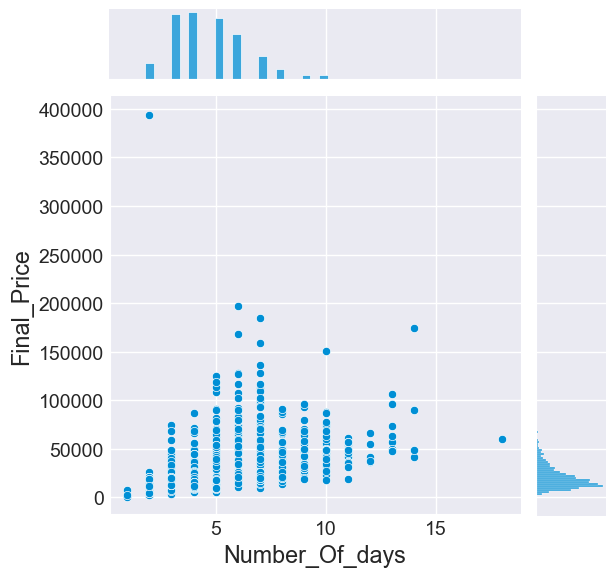

In [47]:
sns.jointplot(x=df['Number_Of_days'],y=df['Final_Price'])
plt.show();

<Axes: xlabel='Discount_Percent', ylabel='Final_Price'>

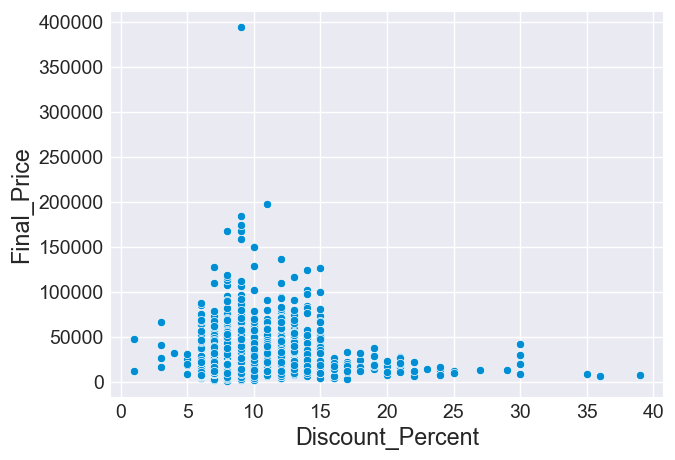

In [48]:
sns.scatterplot(data=df,x=df.Discount_Percent,y=df.Final_Price)

- Two Categorical 

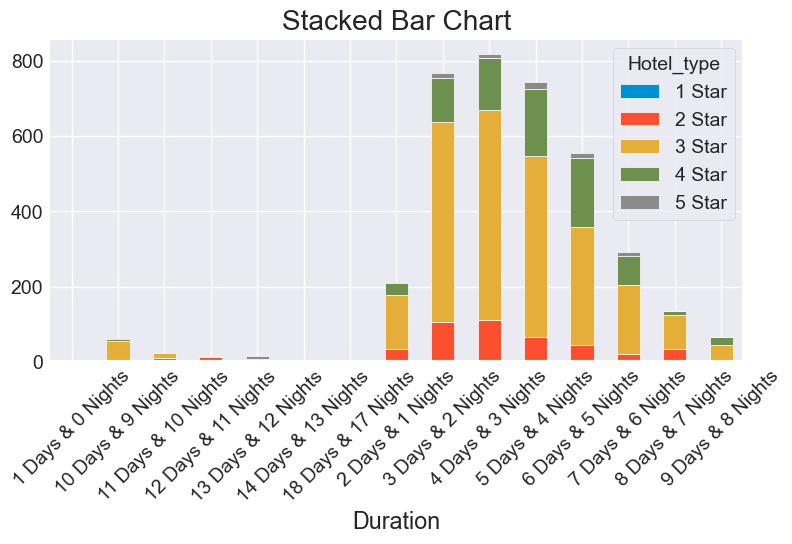

In [9]:
ct = pd.crosstab(df['Duration'], df['Hotel_type'])

# Plot stacked bar chart
ct.plot(kind='bar', stacked=True, figsize=(8,4))

plt.title("Stacked Bar Chart")
plt.xticks(rotation=45)
plt.show();

<Axes: xlabel='Hotel_type', ylabel='Duration'>

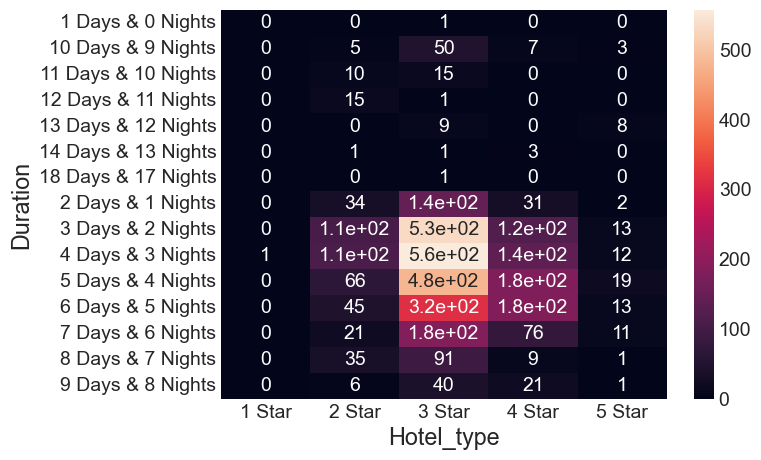

In [4]:
cd=pd.crosstab(df['Duration'],df['Hotel_type'])
sns.heatmap(cd,annot=True)

- One numerical & One Categorical

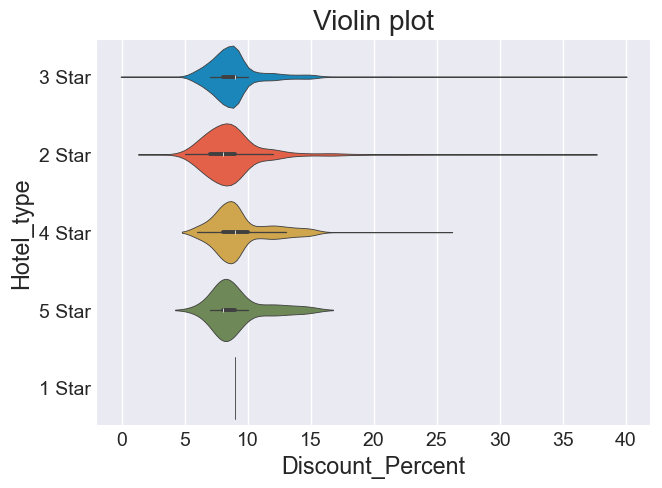

In [7]:
sns.violinplot(data=df,x=df.Discount_Percent,y=df.Hotel_type,palette=sns.color_palette())
plt.title('Violin plot');

## Multivariate Analysis

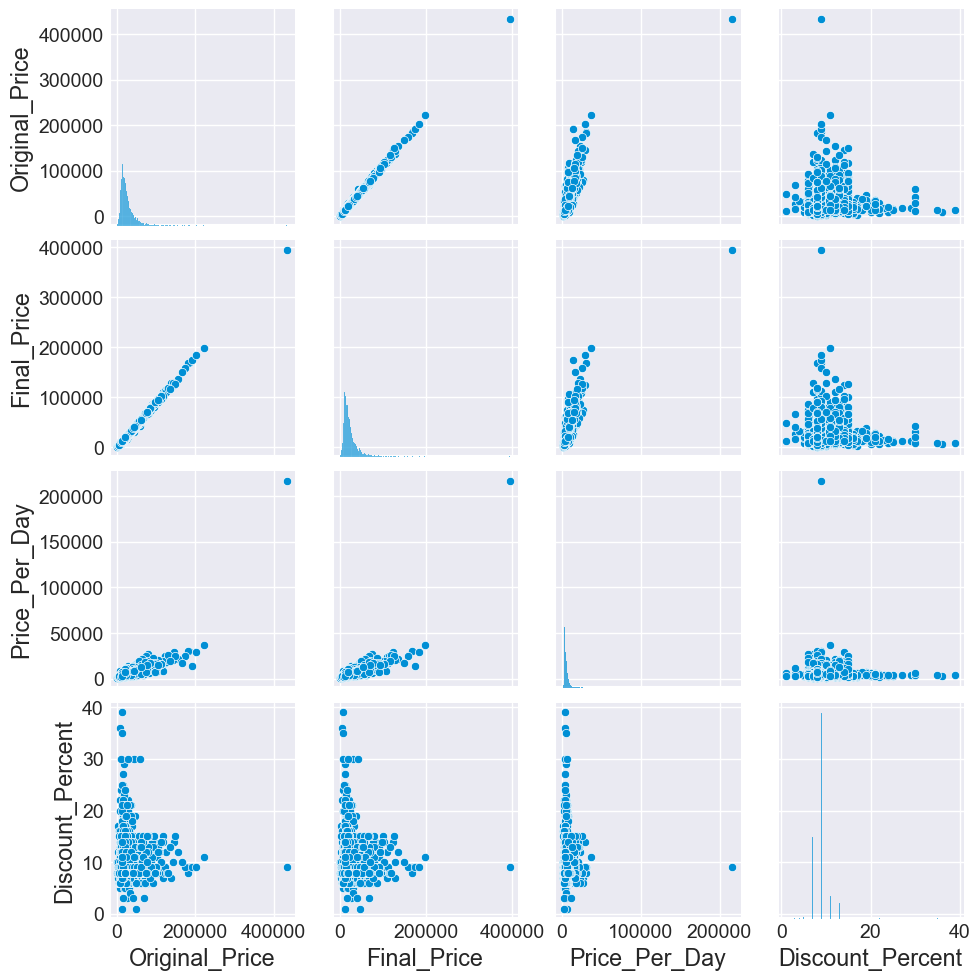

In [86]:
sns.pairplot(df[['Original_Price','Final_Price','Price_Per_Day','Discount_Percent']]);